# 📌 Cell 1: Cài đặt Thư viện & Kiểm tra GPU

In [1]:
# Cell 1: Thư viện
!pip install -q albumentations onnx onnxruntime scikit-learn

import os, json, time, sys
import cv2
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2
import torchvision.models as models
from tqdm import tqdm
from sklearn.metrics import roc_auc_score, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt

# onnx/onnxruntime chỉ cần cho bước Export (Cell 7) -> import "mềm" để không
# làm crash cả notebook nếu môi trường (vd Kaggle) chưa bật Internet để pip install.
try:
    import onnx
    import onnxruntime as ort
    ONNX_AVAILABLE = True
except ModuleNotFoundError:
    ONNX_AVAILABLE = False
    print("⚠️  Không tìm thấy onnx/onnxruntime (có thể do thiếu Internet lúc pip install).")
    print("    Vẫn có thể train/đánh giá model bình thường ở các cell khác.")
    print("    Chỉ cần cài lại (bật Internet trên Kaggle) trước khi chạy Cell 7 (Export ONNX).")

print("PyTorch Version:", torch.__version__)
print("CUDA Available:", torch.cuda.is_available())


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.1/23.1 MB 67.7 MB/s eta 0:00:00
PyTorch Version: 2.10.0+cu128
CUDA Available: True


# 📌 Cell 2: Dataset Definition (CelebA-Spoof 3 Lớp)

In [2]:
class CelebASpoof3ClassDataset(Dataset):
    def __init__(self, root_dir, json_path, transform=None):
        self.root_dir = root_dir
        with open(json_path, 'r') as f:
            self.data = json.load(f)
        self.keys = list(self.data.keys())
        self.transform = transform

    def __len__(self):
        return len(self.keys)

    def __getitem__(self, idx):
        rel_path = self.keys[idx]
        labels = self.data[rel_path]

        img_path = os.path.join(self.root_dir, rel_path)
        image = cv2.imread(img_path)
        if image is None:
            image = np.zeros((224, 224, 3), dtype=np.uint8)
        else:
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        h_img, w_img = image.shape[:2]

        # Đọc bbox từ file <img>_BB.txt riêng
        # Một số file _BB.txt trong dataset bị RỖNG hoặc thiếu đủ 4 giá trị -> phải kiểm tra
        # trước khi unpack, nếu không sẽ crash ValueError giữa lúc train (lỗi dữ liệu, không phải bug code).
        bb_path = os.path.splitext(img_path)[0] + "_BB.txt"
        if os.path.exists(bb_path):
            try:
                with open(bb_path, 'r') as f:
                    parts = f.readline().strip().split()
                if len(parts) >= 4:
                    x, y, w, h = map(float, parts[:4])
                    # Quy đổi từ hệ chuẩn hóa 224 -> pixel thật của ảnh
                    x = x / 224 * w_img
                    y = y / 224 * h_img
                    w = w / 224 * w_img
                    h = h / 224 * h_img

                    max_dim = max(w, h)
                    cx, cy = x + w / 2, y + h / 2
                    crop_size = int(max_dim * 1.5)
                    x1 = max(0, int(cx - crop_size / 2))
                    y1 = max(0, int(cy - crop_size / 2))
                    x2 = min(w_img, x1 + crop_size)
                    y2 = min(h_img, y1 + crop_size)
                    if x2 > x1 and y2 > y1:
                        image = image[y1:y2, x1:x2]
                # else: file _BB.txt rỗng/lỗi -> bỏ qua crop, dùng nguyên ảnh gốc
            except (ValueError, OSError):
                # Phòng hờ file lỗi định dạng khác (không đọc được float, v.v.) -> bỏ qua crop
                pass

        label_raw = int(labels[40])   # ĐÃ XÁC NHẬN: index 40 = spoof type chi tiết
        if label_raw == 0:
            label = 0  # Real
        elif label_raw in [1, 2, 3, 4, 5, 6, 7]:
            label = 1  # Physical Spoof
        else:
            label = 2  # Digital Spoof

        if self.transform:
            augmented = self.transform(image=image)
            image = augmented['image']

        return image, torch.tensor(label, dtype=torch.long)

# 📌 Cell 3: Data Transforms & DataLoaders

In [3]:
# Cell 3: Transforms & DataLoaders
CELEBA_MEAN = [0.5931, 0.4690, 0.4229]
CELEBA_STD = [0.2471, 0.2214, 0.2157]

train_transform = A.Compose([
    A.Resize(224, 224),
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.3),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.05, rotate_limit=15, p=0.3),
    A.Normalize(mean=CELEBA_MEAN, std=CELEBA_STD),
    ToTensorV2(),
])

val_transform = A.Compose([
    A.Resize(224, 224),
    A.Normalize(mean=CELEBA_MEAN, std=CELEBA_STD),
    ToTensorV2(),
])

DATA_ROOT = "/kaggle/input/datasets/attentionlayer241/celeba-spoof-for-face-antispoofing/CelebA_Spoof_/CelebA_Spoof"
TRAIN_JSON = os.path.join(DATA_ROOT, "metas/intra_test/train_label.json")
VAL_JSON = os.path.join(DATA_ROOT, "metas/intra_test/test_label.json")

print(f"Loading Train Metadata from: {TRAIN_JSON}")
print(f"Loading Val Metadata from: {VAL_JSON}")

train_dataset = CelebASpoof3ClassDataset(DATA_ROOT, TRAIN_JSON, transform=train_transform)
val_dataset = CelebASpoof3ClassDataset(DATA_ROOT, VAL_JSON, transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=4, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False, num_workers=4, pin_memory=True)

print(f"--> Dataset Loaded Successfully: Train = {len(train_dataset)} mẫu, Val = {len(val_dataset)} mẫu")


Loading Train Metadata from: /kaggle/input/datasets/attentionlayer241/celeba-spoof-for-face-antispoofing/CelebA_Spoof_/CelebA_Spoof/metas/intra_test/train_label.json
Loading Val Metadata from: /kaggle/input/datasets/attentionlayer241/celeba-spoof-for-face-antispoofing/CelebA_Spoof_/CelebA_Spoof/metas/intra_test/test_label.json


/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


--> Dataset Loaded Successfully: Train = 494405 mẫu, Val = 67170 mẫu


# 📌 Cell 4: Model MobileNetV3-Large Setup

In [4]:
# Cell 4: Model Setup
class AntiSpoofMobileNetV3(nn.Module):
    def __init__(self, dropout_rate=0.35, num_classes=3):
        super(AntiSpoofMobileNetV3, self).__init__()
        weights = models.MobileNet_V3_Large_Weights.DEFAULT
        backbone = models.mobilenet_v3_large(weights=weights)
        
        self.features = backbone.features
        self.avgpool = backbone.avgpool
        in_features = backbone.classifier[0].in_features
        
        self.classifier = nn.Sequential(
            nn.Linear(in_features, 1280),
            nn.Hardswish(inplace=True),
            nn.Dropout(p=dropout_rate),
            nn.Linear(1280, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = AntiSpoofMobileNetV3(dropout_rate=0.35, num_classes=3).to(device)

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20, eta_min=1e-6)
scaler = torch.cuda.amp.GradScaler()


Downloading: "https://download.pytorch.org/models/mobilenet_v3_large-5c1a4163.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_large-5c1a4163.pth


100%|██████████| 21.1M/21.1M [00:00<00:00, 177MB/s]
/tmp/ipykernel_23/1575999002.py:32: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


Một đoạn nhỏ của train_label.json

In [5]:
import json
with open(TRAIN_JSON, 'r') as f:
    data = json.load(f)

keys = list(data.keys())
print("Tổng số ảnh:", len(keys))
print("--- 2 key đầu tiên ---")
for k in keys[:2]:
    print("KEY:", k)
    print("VALUE (type={}, len={}):".format(type(data[k]), len(data[k]) if isinstance(data[k], (list, dict)) else "N/A"))
    print(data[k])
    print()

Tổng số ảnh: 494405
--- 2 key đầu tiên ---
KEY: Data/train/2623/live/000000.jpg
VALUE (type=<class 'list'>, len=44):
[0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0]

KEY: Data/train/5489/spoof/000001.jpg
VALUE (type=<class 'list'>, len=44):
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 6, 1, 1, 1]



Nội dung 1 file _BB.txt mẫu

In [6]:
import os
sample_key = keys[0]
img_path = os.path.join(DATA_ROOT, sample_key)
bb_path = os.path.splitext(img_path)[0] + "_BB.txt"

print("Ảnh có tồn tại không:", os.path.exists(img_path))
print("BB.txt có tồn tại không:", os.path.exists(bb_path))
if os.path.exists(bb_path):
    print("Nội dung BB.txt:")
    print(open(bb_path).read())

# Tiện thể lấy luôn kích thước ảnh thật
import cv2
img = cv2.imread(img_path)
print("Kích thước ảnh thật (H, W):", img.shape[:2] if img is not None else "Không đọc được ảnh")

Ảnh có tồn tại không: True
BB.txt có tồn tại không: True
Nội dung BB.txt:
77 11 48 59 0.9962846

Kích thước ảnh thật (H, W): (550, 500)


# 📌 Cell 5: Training Loop

Không có checkpoint cũ -> train từ epoch 1


Epoch 1/10 [Train]:   0%|          | 0/3863 [00:00<?, ?it/s]/tmp/ipykernel_23/1876700862.py:64: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Epoch 10/10 [Train]: 100%|██████████| 3863/3863 [41:59<00:00,  1.53it/s, loss=0.3004, acc=0.9956]


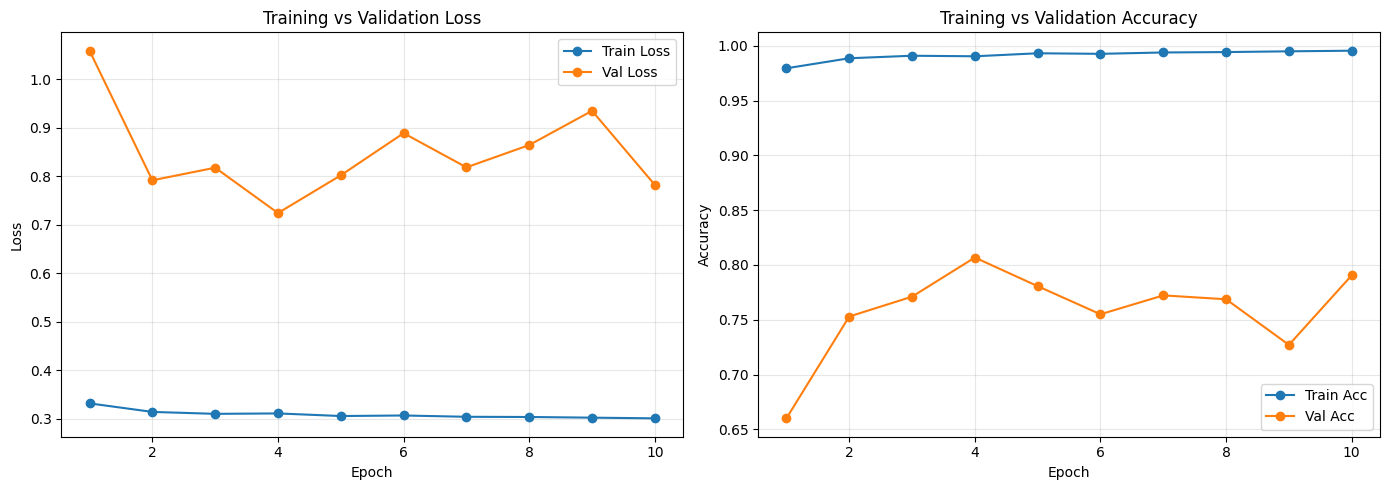

--> Best Val Acc: 0.8068 (checkpoint: best_mnv3_large_3class.pth)
--> Đã train xong tới epoch 10/10. Nếu chưa đủ 10, hãy Commit notebook rồi Add Data output ở version tiếp theo để resume.


In [7]:
# Cell 5: Train Model (checkpoint/resume mỗi epoch + hỗ trợ resume qua Kaggle "Add Data")
#
# CÁCH DÙNG QUA NHIỀU SESSION KAGGLE (do giới hạn ~12h/session):
#   1) Chạy notebook bằng "Save Version" -> "Save & Run All (Commit)". Sau khi chạy xong
#      (hoặc bị dừng do hết giờ), các file trong /kaggle/working (bao gồm checkpoint_last.pth)
#      sẽ được lưu vào phần "Output" của version đó.
#   2) Mở version MỚI của notebook -> "Add Input" -> chọn "Notebook Output Files" -> chọn
#      chính notebook này (output của version trước) -> Kaggle sẽ mount vào
#      /kaggle/input/<ten-notebook>/checkpoint_last.pth
#   3) Điền đường dẫn đó vào CHECKPOINT_INPUT_PATH bên dưới, chạy lại -> tự resume đúng epoch.
#   4) Cứ lặp lại 3 bước trên cho tới khi train đủ `epochs`.

import shutil

CHECKPOINT_PATH = "checkpoint_last.pth"          # nơi LƯU checkpoint của lần chạy này (luôn ghi vào /kaggle/working)
BEST_MODEL_PATH = "best_mnv3_large_3class.pth"

# Nếu đã "Add Data" output của version TRƯỚC (chứa checkpoint_last.pth), điền path vào đây.
# Để "" nếu đây là lần train đầu tiên (chưa có checkpoint nào).
CHECKPOINT_INPUT_PATH = ""  # vd: "/kaggle/input/antiproof-output/checkpoint_last.pth"

epochs = 10
start_epoch = 0
best_val_acc = 0.0
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

# --- Xác định nguồn checkpoint để resume ---
# Ưu tiên 1: checkpoint ngay trong /kaggle/working (đang chạy tiếp trong CÙNG session).
# Ưu tiên 2: checkpoint từ input dataset (resume ở session MỚI qua "Add Data").
resume_source = None
if os.path.exists(CHECKPOINT_PATH):
    resume_source = CHECKPOINT_PATH
elif CHECKPOINT_INPUT_PATH and os.path.exists(CHECKPOINT_INPUT_PATH):
    # /kaggle/input là read-only -> copy về working trước để có thể ghi đè các epoch sau
    shutil.copy(CHECKPOINT_INPUT_PATH, CHECKPOINT_PATH)
    resume_source = CHECKPOINT_PATH

if resume_source is not None:
    ckpt = torch.load(resume_source, map_location=device)
    model.load_state_dict(ckpt["model_state"])
    optimizer.load_state_dict(ckpt["optimizer_state"])
    scheduler.load_state_dict(ckpt["scheduler_state"])
    scaler.load_state_dict(ckpt["scaler_state"])
    start_epoch = ckpt["epoch"] + 1
    best_val_acc = ckpt["best_val_acc"]
    history = ckpt["history"]
    print(f"✅ Tìm thấy checkpoint ({resume_source}) -> resume từ epoch {start_epoch + 1}/{epochs} "
          f"(best_val_acc hiện tại: {best_val_acc:.4f})")
else:
    print("Không có checkpoint cũ -> train từ epoch 1")

if start_epoch >= epochs:
    print(f"🎉 Đã train đủ {epochs} epoch từ trước, không cần train thêm.")

for epoch in range(start_epoch, epochs):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]")

    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()

        with torch.cuda.amp.autocast():
            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct += torch.sum(preds == labels.data).item()
        total += labels.size(0)
        pbar.set_postfix({'loss': f"{running_loss/total:.4f}", 'acc': f"{correct/total:.4f}"})

    scheduler.step()
    history["train_loss"].append(running_loss / total)
    history["train_acc"].append(correct / total)

    # Validation Loop
    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            val_correct += torch.sum(preds == labels.data).item()
            val_total += labels.size(0)

    val_acc = val_correct / val_total
    history["val_loss"].append(val_loss / val_total)
    history["val_acc"].append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), BEST_MODEL_PATH)

    # --- Lưu checkpoint SAU MỖI epoch (để resume trong cùng session hoặc qua Add Data) ---
    torch.save({
        "epoch": epoch,
        "model_state": model.state_dict(),
        "optimizer_state": optimizer.state_dict(),
        "scheduler_state": scheduler.state_dict(),
        "scaler_state": scaler.state_dict(),
        "best_val_acc": best_val_acc,
        "history": history,
    }, CHECKPOINT_PATH)

# --- Vẽ đồ thị Loss & Accuracy qua các epoch đã train (bao gồm cả các lần resume) ---
epochs_range = range(1, len(history["train_loss"]) + 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs_range, history["train_loss"], label="Train Loss", marker='o')
axes[0].plot(epochs_range, history["val_loss"], label="Val Loss", marker='o')
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Training vs Validation Loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(epochs_range, history["train_acc"], label="Train Acc", marker='o')
axes[1].plot(epochs_range, history["val_acc"], label="Val Acc", marker='o')
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Training vs Validation Accuracy")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("training_history.png", dpi=150)
plt.show()

print(f"--> Best Val Acc: {best_val_acc:.4f} (checkpoint: {BEST_MODEL_PATH})")
print(f"--> Đã train xong tới epoch {len(history['train_loss'])}/{epochs}. "
      f"Nếu chưa đủ {epochs}, hãy Commit notebook rồi Add Data output ở version tiếp theo để resume.")


# 📌 Cell 6: ⭐ DUAL TESTING SCRIPT (Đánh giá đồng thời Intra-Test & Cross-Test)

In [8]:
# Cell 6: Dual Testing Script (Intra-Dataset + Cross-Dataset Evaluation)

def evaluate_loader(model, loader, name="Dataset"):
    model.eval()
    y_true = []
    y_scores = []
    y_preds = []

    with torch.no_grad():
        for images, labels in tqdm(loader, desc=f"Evaluating {name}"):
            images = images.to(device)
            outputs = model(images)

            # Tính logit_diff = real_logit - max(spoof_logits)
            real_logit = outputs[:, 0]
            spoof_logit = torch.max(outputs[:, 1:], dim=1)[0]
            logit_diff = (real_logit - spoof_logit).cpu().numpy()

            preds = (logit_diff < 0.0).astype(int) # 0: Real, 1: Spoof
            binary_labels = (labels > 0).long().numpy() # 0: Real, 1: Spoof

            y_true.extend(binary_labels)
            y_scores.extend(-logit_diff) # Score cao nghiêng về Spoof
            y_preds.extend(preds)

    y_true = np.array(y_true)
    y_scores = np.array(y_scores)
    y_preds = np.array(y_preds)

    acc = accuracy_score(y_true, y_preds)
    cm = confusion_matrix(y_true, y_preds)
    TN, FP, FN, TP = cm.ravel()

    APCER = FP / (FP + TN) if (FP + TN) > 0 else 0.0
    BPCER = FN / (FN + TP) if (FN + TP) > 0 else 0.0
    ACER = (APCER + BPCER) / 2.0
    try:
        auc = roc_auc_score(y_true, y_scores)
    except Exception:
        auc = 0.0

    return {
        "Accuracy": acc * 100,
        "APCER": APCER * 100,
        "BPCER": BPCER * 100,
        "ACER/HTER": ACER * 100,
        "AUC": auc * 100
    }

# Nạp model checkpoint tốt nhất
model.load_state_dict(torch.load("best_mnv3_large_3class.pth"))

intra_results = evaluate_loader(model, val_loader, name="CelebA-Spoof (Intra-Test)")
cross_results = evaluate_loader(model, lcc_loader, name="LCC-FASD (Cross-Test)")

# --- Vẽ biểu đồ cột so sánh Intra vs Cross theo từng chỉ số (thay cho bảng in ASCII) ---
metrics = ["Accuracy", "APCER", "BPCER", "ACER/HTER", "AUC"]
intra_vals = [intra_results[m] for m in metrics]
cross_vals = [cross_results[m] for m in metrics]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, intra_vals, width, label="Intra (CelebA-Spoof)")
bars2 = ax.bar(x + width/2, cross_vals, width, label="Cross (LCC-FASD)")

ax.set_ylabel("%")
ax.set_title("So sánh kết quả đánh giá: Intra-Test vs Cross-Test")
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()
ax.grid(axis='y', alpha=0.3)

for bars in (bars1, bars2):
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f"{height:.1f}", xy=(bar.get_x() + bar.get_width()/2, height),
                    xytext=(0, 3), textcoords="offset points", ha='center', fontsize=9)

plt.tight_layout()
plt.savefig("dual_testing_comparison.png", dpi=150)
plt.show()


Evaluating CelebA-Spoof (Intra-Test): 100%|██████████| 525/525 [07:25<00:00,  1.18it/s]


NameError: name 'lcc_loader' is not defined

# 📌 Cell 7: Export ONNX

In [ ]:
# Cell 7: Export ONNX
model.load_state_dict(torch.load("best_mnv3_large_3class.pth"))
model.eval()

dummy_input = torch.randn(1, 3, 224, 224, device=device)
onnx_filename = "mnv3_large_3class_best.onnx"

torch.onnx.export(
    model,
    dummy_input,
    onnx_filename,
    export_params=True,
    opset_version=14,
    do_constant_folding=True,
    input_names=['input'],
    output_names=['output'],
    dynamic_axes={
        'input': {0: 'batch_size'},
        'output': {0: 'batch_size'}
    }
)

onnx_model = onnx.load(onnx_filename)
onnx.checker.check_model(onnx_model)
print("Successfully exported 3-class ONNX model!")
